# ** 4. Comparison of the spatial structures extracted from each regime **

First we apply the POD to the CR and EC subsets separately. For $(Ra = 5 \cdot 10^7 , Pr = 4.3)$, the CR subset is restricted to 100 flow reversals, corresponding to 3157 snapshots taken every 4 convective time units. The sampling frequency of snapshots is adjusted to ensure the different phases of the flow reversals are represented and the number of
snapshots was progressively increased until convergence of POD modes. The EC subset is composed of 3800 snapshots taken every convective time unit. The sampling frequency was increased due to the generally faster dynamics and short duration of this regime. For this regime it was more difficult to obtain converged POD modes and small differences are still observed when considering different sets of snapshots. For $(Ra = 5 \cdot 10^7 , Pr = 3.0)$, the CR subset was composed of 108 reversals, corresponding to 1521 snapshots taken every 4 time units, and the EC subset was composed of 1500 snapshots taken every time unit.

** For the POD routines see pod_using_fortran/ and pod_using_python/ inside HouseCleaning_AC/00_general_post/ **

** This routine concerns figures 2, 3, and 4 from section 4 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the eigenvalues for each subset and plot (figure 2)

In [3]:
eig_pr43_cr = pd.read_csv('./data_from_pod/modes_pr43_cr/pod-eigenvalue-F-complt.asc',sep='\s+',names=['Lambda'])
eig_pr43_ec = pd.read_csv('./data_from_pod/modes_pr43_ec/pod-eigenvalue-F-complt.asc',sep='\s+',names=['Lambda'])

eig_pr3_cr  = pd.read_csv('./data_from_pod/modes_pr3_cr/pod-eigenvalue-F-complt.asc',sep='\s+',names=['Lambda'])
eig_pr3_ec  = pd.read_csv('./data_from_pod/modes_pr3_ec/pod-eigenvalue-F-complt.asc',sep='\s+',names=['Lambda'])

eig_pr43_cr = eig_pr43_cr/eig_pr43_cr.sum()
eig_pr43_ec = eig_pr43_ec/eig_pr43_ec.sum()

eig_pr3_cr = eig_pr3_cr/eig_pr3_cr.sum()
eig_pr3_ec = eig_pr3_ec/eig_pr3_ec.sum()

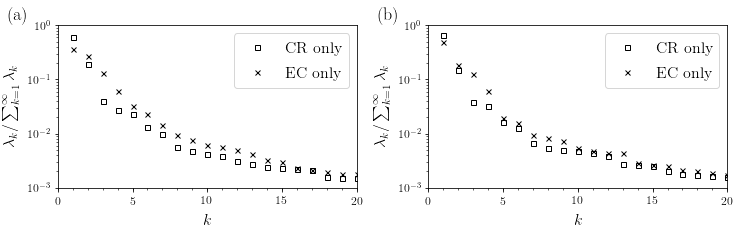

In [4]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

plt.rcParams['figure.figsize'] = (10.5, 3.5)

f, axes = plt.subplots(1,2, sharex=True, sharey=False)
ax= np.ravel(axes)

eig_pr43_cr.plot(ax=ax[1], xlim=[0,20], ylim=[1e-3,1], linestyle='None', legend=False, marker='s', color='k', mfc='none', markersize=5)
eig_pr3_cr.plot( ax=ax[0], xlim=[0,20], ylim=[1e-3,1], linestyle='None', legend=False, marker='s', color='k', mfc='none', markersize=5)

eig_pr43_ec.plot(ax=ax[1], linestyle='None', legend=False, marker='x', color='k', mfc='none', markersize=5)
eig_pr3_ec.plot( ax=ax[0], linestyle='None', legend=False, marker='x', color='k', mfc='none', markersize=5)

## Cosmetics
for i in range (0,2):
    ax[i].set_yscale('log')
    ax[i].set_xlabel('$k$')
    ax[i].set_ylabel('$\lambda_k/\sum_{k=1}^\infty \lambda_k$')
    ax[i].legend(['CR only','EC only'])

    majorLocator_x = MultipleLocator(5)
    minorLocator_x = MultipleLocator(1)
    ax[i].xaxis.set_major_locator(majorLocator_x)
    ax[i].xaxis.set_minor_locator(minorLocator_x)

ax[0].annotate('(a)', xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)    
ax[1].annotate('(b)', xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)    

plt.tight_layout(pad=1.5) 
plt.savefig('figures_for_article/figure2.pdf',dpi=200)

## 2. Read the POD modes stored inside binary files

We define a function to read the POD modes from a gnuplot-compatible binary matrix format. We also define a function to compute the streamfunction from the velocity components. 

In [5]:
def input_matrix(file):   
    import struct
    f = open(file, "rb")
    n = struct.unpack("<f", f.read(4))   
    n = np.array(n[0]).astype(int)    
    y = np.zeros((n,))
    x = np.zeros((n,))
    z = np.zeros((n,n))
    for j in range(n):        
        a = struct.unpack("<f", f.read(4))   
        y[j]=a[0]
        
    for i in range(n):
        a = struct.unpack("<f", f.read(4))   
        x[i]=a[0]
        for j in range(n):        
            a = struct.unpack("<f", f.read(4))   
            z[j,i] = a[0]
            
    return x,y,z ;

def read_fields(file1, file2, file3):
    x,y,T = input_matrix(file1)
    _,_,U = input_matrix(file2)
    _,_,V = input_matrix(file3)
    return x,y,T,U,V ;

def output_matrix(file,n,x,y,z):   
    import struct
    f = open(file, "wb")    
    f.write(struct.pack("<f", n))       
    for j in range(n):        
        f.write(struct.pack("<f", y[j]))       

    for i in range(n):
        f.write(struct.pack("<f", x[i]))       
        for j in range(n):        
            f.write(struct.pack("<f", z[j,i]))       
            
    f.close()
    return ;

def streamfunction(U,V,n): 
    Delta=1./np.float(n)
    dpsi = np.zeros((n,n))    
    for i in range(1,n-1):   
        for j in range(1,n-1):   
            dpsi[i,j] = 0.5*(U[i+1,j] + U[i,j] - V[i,j+1] - V[i,j])*Delta
    vpsi = np.zeros((n,n))
    for i in range(1,n): 
        for j in range(1,n):           
            vpsi[i,j] = vpsi[i-1,j-1] + dpsi[i,j]          
    return vpsi;

### 2.1 Leading POD modes inside the regime of 'Consecutive Reversals'

In [6]:
dir='data_from_pod/modes_pr43_cr'
x,y,T1,U1,V1 = read_fields(dir+'/field-T-000001.bin', dir+'/field-U-000001.bin', dir+'/field-V-000001.bin')
_,_,T2,U2,V2 = read_fields(dir+'/field-T-000002.bin', dir+'/field-U-000002.bin', dir+'/field-V-000002.bin')
_,_,T3,U3,V3 = read_fields(dir+'/field-T-000003.bin', dir+'/field-U-000003.bin', dir+'/field-V-000003.bin')
_,_,T4,U4,V4 = read_fields(dir+'/field-T-000004.bin', dir+'/field-U-000004.bin', dir+'/field-V-000004.bin')
_,_,T5,U5,V5 = read_fields(dir+'/field-T-000005.bin', dir+'/field-U-000005.bin', dir+'/field-V-000005.bin')
_,_,T6,U6,V6 = read_fields(dir+'/field-T-000006.bin', dir+'/field-U-000006.bin', dir+'/field-V-000006.bin')

# Apply symmetries to match with previous works and compute the stream-function $\psi(\vec{x})$
x=-x
T1= -T1; T2= -T2; T3= -T3
T4= -T4; T5= -T5; T6= -T6

V1= -V1; V2= -V2; V3= -V3
V4= -V4; V5= -V5; V6= -V6

Psi1 = streamfunction(U1,V1,512); Psi2 = streamfunction(U2,V2,512); Psi3 = streamfunction(U3,V3,512)
Psi4 = streamfunction(U4,V4,512); Psi5 = streamfunction(U5,V5,512); Psi6 = streamfunction(U6,V6,512)

cr_pr43 = pd.DataFrame({'k1':[T1,U1,V1,Psi1],'k2':[T2,U2,V2,Psi2],'k3':[T3,U3,V3,Psi3],'k4':[T4,U4,V4,Psi4],'k5':[T5,U5,V5,Psi5],'k6':[T6,U6,V6,Psi6]}, index=['T','U','V','Psi'])

In [7]:
dir='data_from_pod/modes_pr3_cr'
_,_,T1,U1,V1 = read_fields(dir+'/field-T-000001.bin', dir+'/field-U-000001.bin', dir+'/field-V-000001.bin')
_,_,T2,U2,V2 = read_fields(dir+'/field-T-000002.bin', dir+'/field-U-000002.bin', dir+'/field-V-000002.bin')
_,_,T3,U3,V3 = read_fields(dir+'/field-T-000003.bin', dir+'/field-U-000003.bin', dir+'/field-V-000003.bin')
_,_,T4,U4,V4 = read_fields(dir+'/field-T-000004.bin', dir+'/field-U-000004.bin', dir+'/field-V-000004.bin')
_,_,T5,U5,V5 = read_fields(dir+'/field-T-000005.bin', dir+'/field-U-000005.bin', dir+'/field-V-000005.bin')
_,_,T6,U6,V6 = read_fields(dir+'/field-T-000006.bin', dir+'/field-U-000006.bin', dir+'/field-V-000006.bin')

# Apply symmetries to match with previous works and compute the stream-function $\psi(\vec{x})$

T1= -T1; T2= -T2; T3= -T3
T4= -T4; T5= -T5; T6= -T6

V1= -V1; V2= -V2; V3= -V3
V4= -V4; V5= -V5; V6= -V6

T3=np.flip(T3,axis=1); U3=np.flip(-U3,axis=1); V3=np.flip(V3,axis=1);
T4=np.flip(T4,axis=1); U4=np.flip(-U4,axis=1); V4=np.flip(V4,axis=1); 

Psi1 = streamfunction(U1,V1,512); Psi2 = streamfunction(U2,V2,512); Psi3 = streamfunction(U3,V3,512)
Psi4 = streamfunction(U4,V4,512); Psi5 = streamfunction(U5,V5,512); Psi6 = streamfunction(U6,V6,512)
    
cr_pr3 = pd.DataFrame({'k1':[T1,U1,V1,Psi1],'k2':[T2,U2,V2,Psi2],'k3':[T3,U3,V3,Psi3],'k4':[T4,U4,V4,Psi4],'k5':[T5,U5,V5,Psi5],'k6':[T6,U6,V6,Psi6]}, index=['T','U','V','Psi'])

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


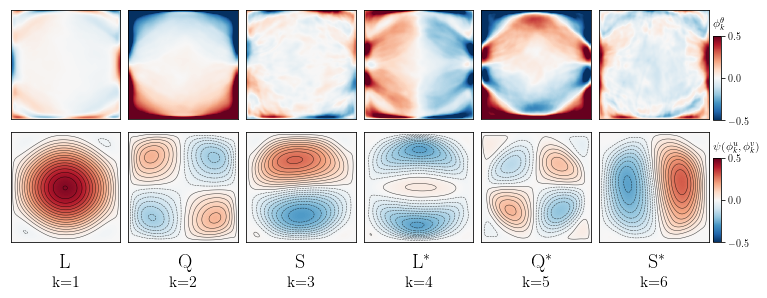

In [8]:
plt.rcParams['figure.figsize'] = (10.5, 4.25)
f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

vmin=-0.5; vmax=0.5; i=0
for k in ['k1','k2','k4','k3','k5','k6']:
    im1=ax[i].imshow(cr_pr43.loc['T',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    i= i+1

vmin=-0.50 ; vmax=0.50; levels=(np.arange(vmin,vmax,0.03))
for k in ['k1','k2','k4','k3','k5','k6']:
    im2=ax[i].imshow(cr_pr43.loc['Psi',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(x,y,cr_pr43.loc['Psi',k],levels, colors='k',linewidths=0.5, alpha=0.75)
    i= i+1 

ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

labels=['L', 'Q', 'S', 'L$^*$', 'Q$^*$', 'S$^*$']
for i in range(6):
    ax[i+6].annotate(labels[i], xy=(0.45,0), xycoords='axes fraction', xytext=(0,-25), textcoords='offset points', fontsize=20)
    ax[i+6].annotate('k='+str(i+1), xy=(0.375,0), xycoords='axes fraction', xytext=(0,-45), textcoords='offset points', fontsize=16)    

    
cb_ax = f.add_axes([0.935, 0.595, 0.01, 0.275])
cbar = f.colorbar(im1, cax=cb_ax)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\phi_k^{\\theta}$', loc='left')

cb_ax2 = f.add_axes([0.935, 0.195, 0.01, 0.275])
cbar = f.colorbar(im2, cax=cb_ax2)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\psi(\phi_k^{u}, \phi_k^{v})$', loc='left')

plt.tight_layout(pad=0.1, rect=[0, 0.15, 0.935, 1.0]) 
plt.savefig('figures_for_article/figure3a.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


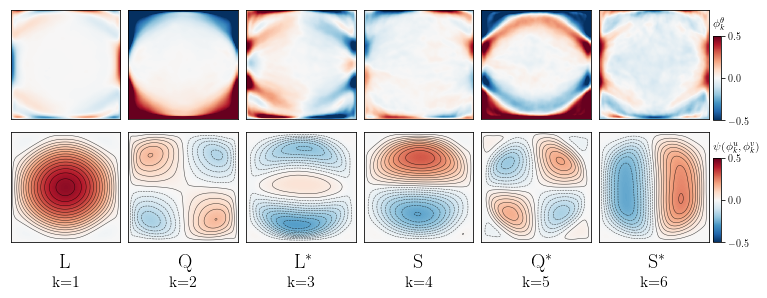

In [9]:
plt.rcParams['figure.figsize'] = (10.5, 4.25)
f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

vmin=-0.5; vmax=0.5; i=0
for k in ['k1','k2','k4','k3','k5','k6']:
    im1=ax[i].imshow(cr_pr3.loc['T',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    i= i+1

vmin=-0.5 ; vmax=0.5; levels=(np.arange(vmin,vmax,0.03))
for k in ['k1','k2','k4','k3','k5','k6']:
    im2=ax[i].imshow(cr_pr3.loc['Psi',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(x,y,cr_pr3.loc['Psi',k],levels, colors='k',linewidths=0.5, alpha=0.75)
    i= i+1 

ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

labels=['L', 'Q', 'L$^*$', 'S', 'Q$^*$', 'S$^*$']
for i in range(6):
    ax[i+6].annotate(labels[i], xy=(0.45,0), xycoords='axes fraction', xytext=(0,-25), textcoords='offset points', fontsize=20)
    ax[i+6].annotate('k='+str(i+1), xy=(0.375,0), xycoords='axes fraction', xytext=(0,-45), textcoords='offset points', fontsize=16)    

cb_ax = f.add_axes([0.935, 0.595, 0.01, 0.275])
cbar = f.colorbar(im1, cax=cb_ax)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\phi_k^{\\theta}$', loc='left')

cb_ax2 = f.add_axes([0.935, 0.195, 0.01, 0.275])
cbar = f.colorbar(im2, cax=cb_ax2)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\psi(\phi_k^{u}, \phi_k^{v})$', loc='left')

plt.tight_layout(pad=0.1, rect=[0, 0.15, 0.935, 1.0]) 
plt.savefig('figures_for_article/figure3b.pdf',dpi=300)

### 2.2 Leading POD modes inside the regime of 'Extended Cessations'

In [10]:
dir='data_from_pod/modes_pr43_ec'
x,y,T1,U1,V1 = read_fields(dir+'/field-T-000001.bin', dir+'/field-U-000001.bin', dir+'/field-V-000001.bin')
_,_,T2,U2,V2 = read_fields(dir+'/field-T-000002.bin', dir+'/field-U-000002.bin', dir+'/field-V-000002.bin')
_,_,T3,U3,V3 = read_fields(dir+'/field-T-000003.bin', dir+'/field-U-000003.bin', dir+'/field-V-000003.bin')
_,_,T4,U4,V4 = read_fields(dir+'/field-T-000004.bin', dir+'/field-U-000004.bin', dir+'/field-V-000004.bin')
_,_,T5,U5,V5 = read_fields(dir+'/field-T-000005.bin', dir+'/field-U-000005.bin', dir+'/field-V-000005.bin')
_,_,T6,U6,V6 = read_fields(dir+'/field-T-000006.bin', dir+'/field-U-000006.bin', dir+'/field-V-000006.bin')


T1= -T1; T2= -T2; T3= -T3
T4= -T4; T5= -T5; T6= -T6

V1= -V1; V2= -V2; V3= -V3
V4= -V4; V5= -V5; V6= -V6

T1=np.flip(np.flip(-T1,axis=1),axis=0); U1=np.flip(np.flip(-U1,axis=1),axis=0); V1=np.flip(np.flip(-V1,axis=1),axis=0);
T2=np.flip(T2,axis=1); U2=np.flip(-U2,axis=1); V2=np.flip(V2,axis=1);

T4=np.flip(np.flip(-T4,axis=1),axis=0); U4=np.flip(np.flip(-U4,axis=1),axis=0); V4=np.flip(np.flip(-V4,axis=1),axis=0);

Psi1 = streamfunction(U1,V1,512); Psi2 = streamfunction(U2,V2,512); Psi3 = streamfunction(U3,V3,512)
Psi4 = streamfunction(U4,V4,512); Psi5 = streamfunction(U5,V5,512); Psi6 = streamfunction(U6,V6,512)

ec_pr43 = pd.DataFrame({'k1':[T1,U1,V1,Psi1],'k2':[T2,U2,V2,Psi2],'k3':[T3,U3,V3,Psi3],'k4':[T4,U4,V4,Psi4],'k5':[T5,U5,V5,Psi5],'k6':[T6,U6,V6,Psi6]}, index=['T','U','V','Psi'])

In [11]:
dir='data_from_pod/modes_pr3_ec'
_,_,T1,U1,V1 = read_fields(dir+'/field-T-000001.bin', dir+'/field-U-000001.bin', dir+'/field-V-000001.bin')
_,_,T2,U2,V2 = read_fields(dir+'/field-T-000002.bin', dir+'/field-U-000002.bin', dir+'/field-V-000002.bin')
_,_,T3,U3,V3 = read_fields(dir+'/field-T-000003.bin', dir+'/field-U-000003.bin', dir+'/field-V-000003.bin')
_,_,T4,U4,V4 = read_fields(dir+'/field-T-000004.bin', dir+'/field-U-000004.bin', dir+'/field-V-000004.bin')
_,_,T5,U5,V5 = read_fields(dir+'/field-T-000005.bin', dir+'/field-U-000005.bin', dir+'/field-V-000005.bin')
_,_,T6,U6,V6 = read_fields(dir+'/field-T-000006.bin', dir+'/field-U-000006.bin', dir+'/field-V-000006.bin')

# Apply symmetries to match with previous works and compute the stream-function $\psi(\vec{x})$

T1= -T1; T2= -T2; T3= -T3
T4= -T4; T5= -T5; T6= -T6

V1= -V1; V2= -V2; V3= -V3
V4= -V4; V5= -V5; V6= -V6

#T1=np.flip(np.flip(-T1,axis=1),axis=0); U1=np.flip(np.flip(-U1,axis=1),axis=0); V1=np.flip(np.flip(-V1,axis=1),axis=0);
T1=np.flip(T1,axis=1); U1=np.flip(-U1,axis=1); V1=np.flip(V1,axis=1);

Psi1 = streamfunction(U1,V1,512); Psi2 = streamfunction(U2,V2,512); Psi3 = streamfunction(U3,V3,512)
Psi4 = streamfunction(U4,V4,512); Psi5 = streamfunction(U5,V5,512); Psi6 = streamfunction(U6,V6,512)
    
ec_pr3 = pd.DataFrame({'k1':[T1,U1,V1,Psi1],'k2':[T2,U2,V2,Psi2],'k3':[T3,U3,V3,Psi3],'k4':[T4,U4,V4,Psi4],'k5':[T5,U5,V5,Psi5],'k6':[T6,U6,V6,Psi6]}, index=['T','U','V','Psi'])

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


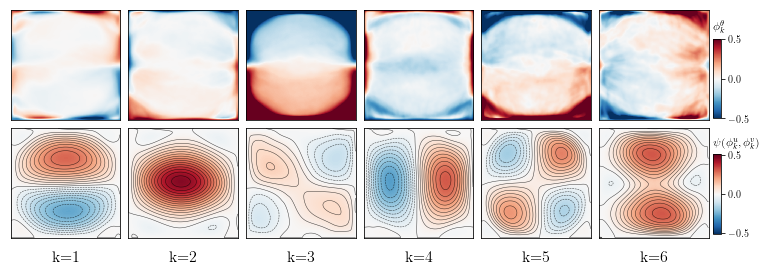

In [12]:
plt.rcParams['figure.figsize'] = (10.5, 4.0)
f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

vmin=-0.5; vmax=0.5; i=0
for k in ['k1','k2','k3','k4','k5','k6']:
    im1=ax[i].imshow(ec_pr43.loc['T',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    i= i+1

vmin=-0.51 ; vmax=0.51; levels=(np.arange(vmin,vmax,0.03))
for k in ['k1','k2','k3','k4','k5','k6']:
    im2=ax[i].imshow(ec_pr43.loc['Psi',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(-x,y,ec_pr43.loc['Psi',k],levels, colors='k',linewidths=0.5, alpha=0.75)
    i= i+1 

ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

for i in range(6):
    ax[i+6].annotate('k='+str(i+1), xy=(0.375,0), xycoords='axes fraction', xytext=(0,-25), textcoords='offset points', fontsize=16)    

cb_ax = f.add_axes([0.935, 0.595, 0.01, 0.275])
cbar = f.colorbar(im1, cax=cb_ax)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\phi_k^{\\theta}$', loc='left')

cb_ax2 = f.add_axes([0.935, 0.195, 0.01, 0.275])
cbar = f.colorbar(im2, cax=cb_ax2)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\psi(\phi_k^{u}, \phi_k^{v})$', loc='left')

plt.tight_layout(pad=0.1, rect=[0, 0.15, 0.935, 1.0]) 
plt.savefig('figures_for_article/figure4a.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


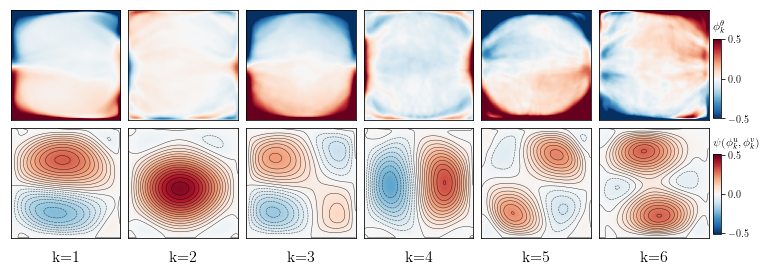

In [13]:
plt.rcParams['figure.figsize'] = (10.5, 4.0)
f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

vmin=-0.5; vmax=0.5; i=0
for k in ['k1','k2','k3','k4','k5','k6']:
    im1=ax[i].imshow(ec_pr3.loc['T',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    i= i+1

vmin=-0.51 ; vmax=0.51; levels=(np.arange(vmin,vmax,0.03))
for k in ['k1','k2','k3','k4','k5','k6']:
    im2=ax[i].imshow(ec_pr3.loc['Psi',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(-x,y,ec_pr3.loc['Psi',k],levels, colors='k',linewidths=0.5, alpha=0.75)
    i= i+1 

ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

for i in range(6):
    ax[i+6].annotate('k='+str(i+1), xy=(0.375,0), xycoords='axes fraction', xytext=(0,-25), textcoords='offset points', fontsize=16)    

cb_ax = f.add_axes([0.935, 0.595, 0.01, 0.275])
cbar = f.colorbar(im1, cax=cb_ax)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\phi_k^{\\theta}$', loc='left')

cb_ax2 = f.add_axes([0.935, 0.195, 0.01, 0.275])
cbar = f.colorbar(im2, cax=cb_ax2)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\psi(\phi_k^{u}, \phi_k^{v})$', loc='left')

plt.tight_layout(pad=0.1, rect=[0, 0.15, 0.935, 1.0]) 
plt.savefig('figures_for_article/figure4b.pdf',dpi=300)

## 3. We save the POD modes to be used in the other routines

In [14]:
import pickle

filename_pr3 = './data_from_pod/pod_modes_pr3_cr.sav'
pickle.dump(cr_pr3, open(filename_pr3, 'wb'))

filename_pr43 = './data_from_pod/pod_modes_pr43_cr.sav'
pickle.dump(cr_pr43, open(filename_pr43, 'wb'))

# **Made during revision 1**

In [27]:
dir='data_from_pod/modes_pr43_full'
x,y,T1,U1,V1 = read_fields(dir+'/field-T-000001.bin', dir+'/field-U-000001.bin', dir+'/field-V-000001.bin')
_,_,T2,U2,V2 = read_fields(dir+'/field-T-000002.bin', dir+'/field-U-000002.bin', dir+'/field-V-000002.bin')
_,_,T3,U3,V3 = read_fields(dir+'/field-T-000003.bin', dir+'/field-U-000003.bin', dir+'/field-V-000003.bin')
_,_,T4,U4,V4 = read_fields(dir+'/field-T-000004.bin', dir+'/field-U-000004.bin', dir+'/field-V-000004.bin')
_,_,T5,U5,V5 = read_fields(dir+'/field-T-000005.bin', dir+'/field-U-000005.bin', dir+'/field-V-000005.bin')
_,_,T6,U6,V6 = read_fields(dir+'/field-T-000006.bin', dir+'/field-U-000006.bin', dir+'/field-V-000006.bin')

# Apply symmetries to match with previous works and compute the stream-function $\psi(\vec{x})$
x=-x
T2= -T2; T5= -T5; T6= -T6

U1 = -U1 ; U3 = -U3; U4 = -U4

V2= -V2; V5= -V5; V6= -V6

Psi1 = streamfunction(U1,V1,512); Psi2 = streamfunction(U2,V2,512); Psi3 = streamfunction(U3,V3,512)
Psi4 = streamfunction(U4,V4,512); Psi5 = streamfunction(U5,V5,512); Psi6 = streamfunction(U6,V6,512)

full_pr43 = pd.DataFrame({'k1':[T1,U1,V1,Psi1],'k2':[T2,U2,V2,Psi2],'k3':[T3,U3,V3,Psi3],'k4':[T4,U4,V4,Psi4],'k5':[T5,U5,V5,Psi5],'k6':[T6,U6,V6,Psi6]}, index=['T','U','V','Psi'])

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


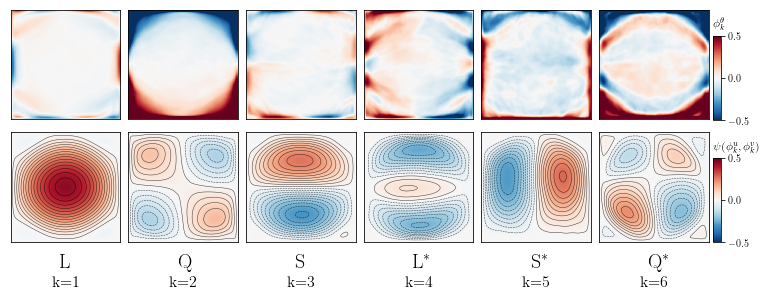

In [30]:
plt.rcParams['figure.figsize'] = (10.5, 4.25)
f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

vmin=-0.5; vmax=0.5; i=0
for k in ['k1','k2','k3','k4','k5','k6']:
    im1=ax[i].imshow(full_pr43.loc['T',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    i= i+1

vmin=-0.50 ; vmax=0.50; levels=(np.arange(vmin,vmax,0.03))
for k in ['k1','k2','k3','k4','k5','k6']:
    im2=ax[i].imshow(full_pr43.loc['Psi',k],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(x,y,full_pr43.loc['Psi',k],levels, colors='k',linewidths=0.5, alpha=0.75)
    i= i+1 

ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

labels=['L', 'Q', 'S', 'L$^*$', 'S$^*$', 'Q$^*$']
for i in range(6):
    ax[i+6].annotate(labels[i], xy=(0.45,0), xycoords='axes fraction', xytext=(0,-25), textcoords='offset points', fontsize=20)
    ax[i+6].annotate('k='+str(i+1), xy=(0.375,0), xycoords='axes fraction', xytext=(0,-45), textcoords='offset points', fontsize=16)    

    
cb_ax = f.add_axes([0.935, 0.595, 0.01, 0.275])
cbar = f.colorbar(im1, cax=cb_ax)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\phi_k^{\\theta}$', loc='left')

cb_ax2 = f.add_axes([0.935, 0.195, 0.01, 0.275])
cbar = f.colorbar(im2, cax=cb_ax2)
cbar.set_ticks(np.arange(-0.5, 0.6, 0.5))
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('$\psi(\phi_k^{u}, \phi_k^{v})$', loc='left')

plt.tight_layout(pad=0.1, rect=[0, 0.15, 0.935, 1.0]) 
plt.savefig('figures_for_article/new_figure2.pdf',dpi=300)